# Superstore Analysis
This notebook is a split, interactive version of `run.py`. Run cells in order: imports, file paths, functions, pipeline, then visualisations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# File paths
raw_file_path = "Superstore-data.csv"
cleaned_file_path = "Superstore-data-cleaned.csv"

In [4]:
def load_data(file_path):
    try:
        df = pd.read_csv(file_path, encoding="utf-8")
        print("File loaded successfully with UTF-8 encoding.")
    except UnicodeDecodeError as error:
        print("UTF-8 failed.")
        print("Error message:")
        print(error)
        print("\nTrying again with latin1 encoding...")
        df = pd.read_csv(file_path, encoding='latin1')
        print("File loaded successfully with latin1 encoding.")
    print("Finished load_data()")
    print(f"Rows loaded: {df.shape[0]}")
    print(f"Columns loaded: {df.shape[1]}")
    print("First 5 rows:")
    print(df.head())
    print("\nData types when first loaded:")
    print(df.dtypes)
    print("\nSummary of numeric columns:")
    print(df.describe())
    return df

In [5]:
def clean_column_names(df):
    print("Column names before cleaning:")
    print(df.columns)
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    print("column names after cleaning:")
    print(df.columns)
    return df

In [6]:
def check_and_transform_data_types(df):
    print("\nData types before transformation")
    print(df.dtypes)
    df['postal_code'] = df['postal_code'].astype(str)
    df["order_date"] = pd.to_datetime(df["order_date"], format="%m/%d/%Y")
    df["ship_date"] = pd.to_datetime(df["ship_date"], format="%m/%d/%Y")
    print("\nData types after transformation:")
    print(df.dtypes)
    return df

In [7]:
def check_missing_values(df):
    print("\nMissing values in each column:")
    print(df.isnull().sum())
    return df

def check_duplicate_rows(df):
    print("\nNumber of duplicate rows:")
    print(df.duplicated().sum())
    return df

def check_shipping_dates(df):
    invalid_dates = df[df["ship_date"] < df["order_date"]]
    print("\nInvalid shipping dates (before order date):")
    print("\nRows where ship_date is before order_date")
    print(len(invalid_dates))
    return df

def check_numeric_values(df):
    print("\nNumeric summary:")
    print(df[["sales", "quantity", "discount", "profit"]].describe())
    print("\nRows with sales <= 0:")
    print((df["sales"] <= 0).sum())
    print("\nRows with quantity <= 0:")
    print((df["quantity"] <= 0).sum())
    print("\nRows with discount outside 0 to 1:")
    print(((df["discount"] < 0) | (df["discount"] > 1)).sum())
    return df

def check_outliers(df):
    print("\n--- Checking for Outliers---")
    numeric_columns = ["sales", "quantity", "discount", "profit"]
    for column in numeric_columns:
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower_limit = q1 - 1.5 * iqr
        upper_limit = q3 + 1.5 * iqr
        outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]
        print(f"Number of possible outliers in {column}: {len(outliers)}")
    return df

In [8]:
def numpy_column_summary(df, column_name):
    values = df[column_name].to_numpy()
    print(f"\n--- {column_name.title()} Analysis ---")
    print("Mean:", np.mean(values))
    print("Median:", np.median(values))
    print("Standard deviation:", np.std(values))
    print("Maximum:", np.max(values))
    print("Minimum:", np.min(values))
    print("25th pct:", np.percentile(values, 25))
    print("50th pct:", np.percentile(values, 50))
    print("75th pct:", np.percentile(values, 75))
    return df

In [10]:
# Run the pipeline step-by-step
df = load_data(raw_file_path)
df = clean_column_names(df)
df = check_and_transform_data_types(df)
df = check_missing_values(df)
df = check_duplicate_rows(df)
df = check_shipping_dates(df)
df = check_numeric_values(df)
df = check_outliers(df)
# Add calculated columns
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days
df["profit_margin"] = df["profit"] / df["sales"]
print("\nFinal cleaned dataset shape:")
print(df.shape)
print("Columns after adding calculated columns:")
print(df.columns)
print("Preview of calculated columns:")
print(df[["order_date", "ship_date", "shipping_days", "sales", "profit", "profit_margin"]].head())

UTF-8 failed.
Error message:
'utf-8' codec can't decode byte 0xf6 in position 9: invalid start byte

Trying again with latin1 encoding...
File loaded successfully with latin1 encoding.
Finished load_data()
Rows loaded: 9994
Columns loaded: 21
First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States  


--- Sales Analysis ---
Mean: 229.85800083049833
Median: 54.489999999999995
Standard deviation: 623.2139187650461
Maximum: 22638.48
Minimum: 0.444
25th pct: 17.28
50th pct: 54.489999999999995
75th pct: 209.94

--- Quantity Analysis ---
Mean: 3.789573744246548
Median: 3.0
Standard deviation: 2.224998366078609
Maximum: 14
Minimum: 1
25th pct: 2.0
50th pct: 3.0
75th pct: 5.0

--- Profit Analysis ---
Mean: 28.65689630778467
Median: 8.6665
Standard deviation: 234.2483873603588
Maximum: 8399.976
Minimum: -6599.978
25th pct: 1.72875
50th pct: 8.6665
75th pct: 29.364

--- Discount Analysis ---
Mean: 0.15620272163297977
Median: 0.2
Standard deviation: 0.2064416387716596
Maximum: 0.8
Minimum: 0.0
25th pct: 0.0
50th pct: 0.2
75th pct: 0.2

--- Shipping_Days Analysis ---
Mean: 3.958174904942966
Median: 4.0
Standard deviation: 1.747479304993179
Maximum: 7
Minimum: 0
25th pct: 3.0
50th pct: 4.0
75th pct: 5.0

--- Profit_Margin Analysis ---
Mean: 0.12031392972104459
Median: 0.27
Standard deviation: 0

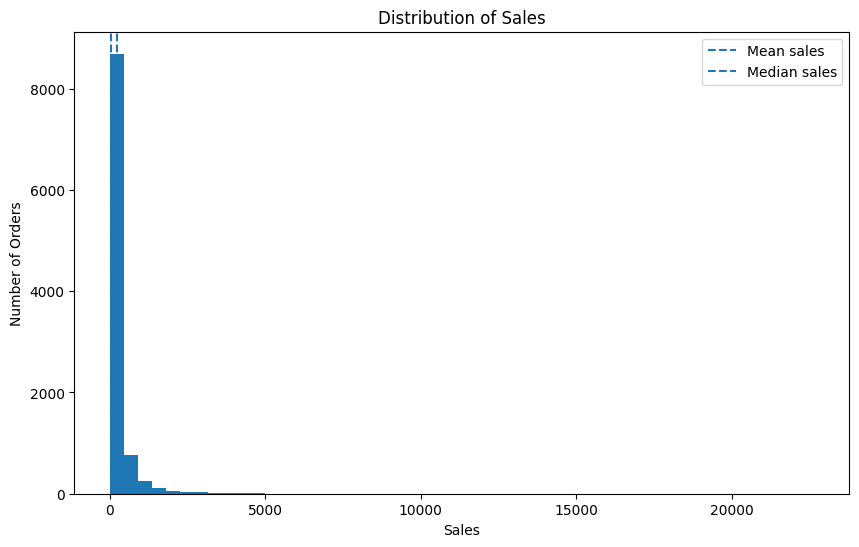

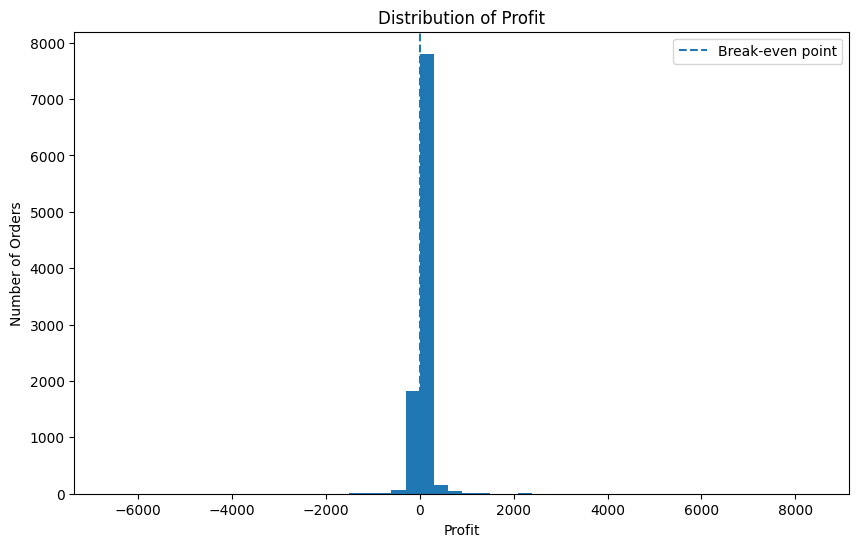

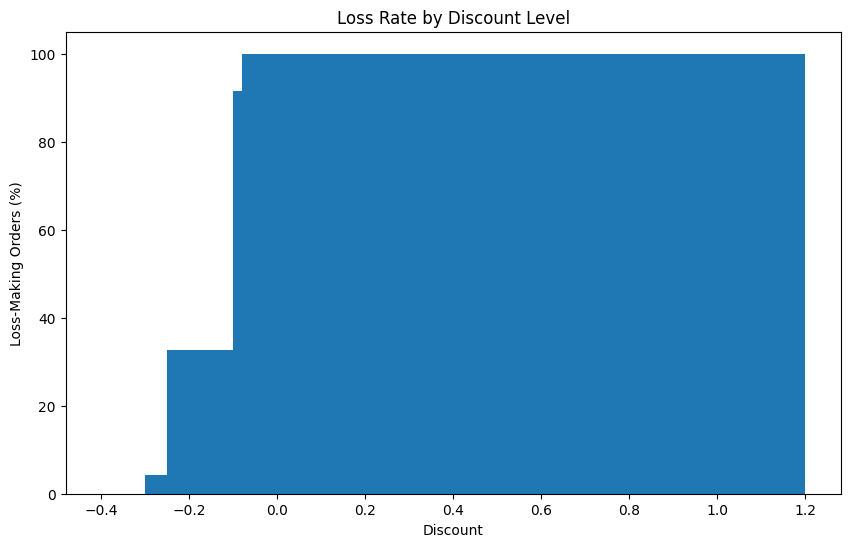

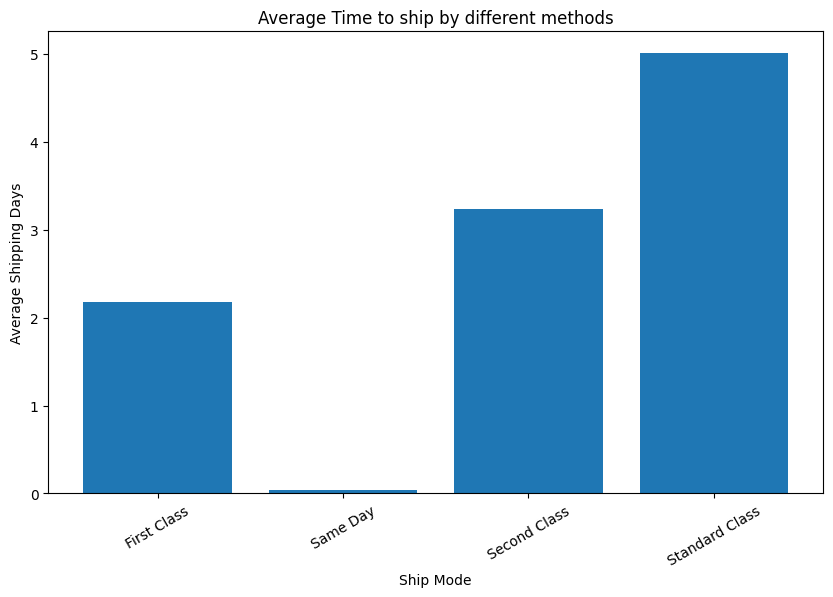

In [11]:
# Numpy summaries and visualisations
df = numpy_column_summary(df, "sales")
df = numpy_column_summary(df, "quantity")
df = numpy_column_summary(df, "profit")
df = numpy_column_summary(df, "discount")
df = numpy_column_summary(df, "shipping_days")
df = numpy_column_summary(df, "profit_margin")
plt.figure(figsize=(10,6))
plt.hist(df["sales"], bins=50)
plt.axvline(np.mean(df["sales"]), linestyle="--", label="Mean sales")
plt.axvline(np.median(df["sales"]), linestyle="--", label="Median sales")
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")
plt.legend()
plt.show()
plt.figure(figsize=(10,6))
plt.hist(df["profit"], bins=50)
plt.axvline(0, linestyle="--", label="Break-even point")
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Number of Orders")
plt.legend()
plt.show()
loss_rate_by_discount = df.groupby("discount")["profit"].apply(lambda x: (x < 0).mean() * 100)
plt.figure(figsize=(10,6))
plt.bar(loss_rate_by_discount.index, loss_rate_by_discount.values)
plt.title("Loss Rate by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Loss-Making Orders (%)")
plt.show()
shipping_by_mode = df.groupby("ship_mode")["shipping_days"].mean()
plt.figure(figsize=(10,6))
plt.bar(shipping_by_mode.index, shipping_by_mode.values)
plt.title("Average Time to ship by different methods")
plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Days")
plt.xticks(rotation=30)
plt.show()